## Multi-Layer Perceptron for Approximate Low-thrust Transfers

This notebook is for training a Multi-layer Perceptron (MLP) for approximating cost of low-thrust trajectories in the Main Asteroid Belt (MAB). The work is based on the paper: [Acciarini, G., Beauregard, L., & Izzo, D. (2024), Computing low-thrust transfers in the asteroid belt, a comparison between astrodynamical manipulations and a machine learning approach.](https://www.researchgate.net/publication/380974504_Computing_low-thrust_transfers_in_the_asteroid_belt_a_comparison_between_astrodynamical_manipulations_and_a_machine_learning_approach/figures)

And the dataset is downloaded from the [Zenodo link](https://data.niaid.nih.gov/resources?id=zenodo_10972837) provided by the authors. In particular, the ```fuel_optimal_db.txt``` is used and modified accordingly to be read as a ```.csv``` (e.g., adding commas and removing spaces from the columns' names).

### Step 0: Import libraries

In this step, libraries are imported. [Tensorflow](https://www.tensorflow.org) is used to build the MLP architecture.

In [11]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Step 1: Data preparation

The dataset is loaded and processed. In particular, the columns ```["mima [kg]", "mima2 [kg]", "mima3 [kg]", "mfms_approx"]``` are dropped as these only represent other approximations to the described transfers, thus not adding much to the MLP predictions.

The predicted value should be the ratio between the target mass of the spacecraft at the end of the transfer (i.e., ```mt [kg]```) and the initial mass (i.e., ```ms [kg]```). In this way, the output variable is in the range ```[0-1]```.

A train-test split is performed, assuming 20% of the dataset used for testing.

The train set is fitted and scaled by centering and scaled, while the test set is only scaled. This allows to simulate the fact that unseen data are passed to the model.

In [12]:
# define the file path
file_path = "datasets/fuel_optimal_db.csv"

# Load the data using pandas
data = pd.read_csv(file_path)

# drop unused columns
columns_to_drop = ["mima [kg]", "mima2 [kg]", "mima3 [kg]", "mfms_approx"]
data = data.drop(columns=columns_to_drop)

# Preprocess data
y = data["mt [kg]"] / data["ms [kg]"] # put the data in 0-1 range
X = data.drop("mt [kg]", axis=1)

# split data in train and test -- 20% of the dataset is used for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

### Step 2: MLP

A simple MLP is built using an input and normalization layers, followed by 2 hidden layers with 64 and 32 neurons, respectively. The output layer only has one neuron since a single value is desired as target. A sigmoid is used as activation function for output layer, since it is expected that the output is in the ```[0-1]``` range.

The loss is mean squared error (MSE), while the metric is the mean absolute error (MAE). 

In [14]:
# Multi Layer Perceptron using Pytorch

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.BatchNorm1d(input_size),
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


The model is then trained for 10 epochs.

In [15]:
epochs = 10
batch_size = 32
train_size = X_train_tensor.size(0)

loss_history = []
mae_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_mae = 0.0

    # Mini-batch training
    for i in range(0, train_size, batch_size):
        X_batch = X_train_tensor[i:i+batch_size]
        y_batch = y_train_tensor[i:i+batch_size].unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_mae += torch.mean(torch.abs(outputs - y_batch)).item()

    epoch_loss = running_loss / (train_size // batch_size)
    epoch_mae = running_mae / (train_size // batch_size)

    loss_history.append(epoch_loss)
    mae_history.append(epoch_mae)
    
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss:.4f}, MAE: {epoch_mae:.4f}")


Epoch [1/10], Loss: 0.0016, MAE: 0.0293
Epoch [2/10], Loss: 0.0011, MAE: 0.0255
Epoch [3/10], Loss: 0.0011, MAE: 0.0251
Epoch [4/10], Loss: 0.0011, MAE: 0.0250
Epoch [5/10], Loss: 0.0011, MAE: 0.0249
Epoch [6/10], Loss: 0.0011, MAE: 0.0248
Epoch [7/10], Loss: 0.0011, MAE: 0.0248
Epoch [8/10], Loss: 0.0011, MAE: 0.0248
Epoch [9/10], Loss: 0.0010, MAE: 0.0248
Epoch [10/10], Loss: 0.0010, MAE: 0.0247


In [18]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).cpu().numpy()

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
mpe = sum(abs(y_pred.flatten() - y_test.to_numpy())/y_test.to_numpy())/len(y_test) * 100

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Percentage Error (MPE): {mpe:.4f} %")

Mean Absolute Error (MAE): 0.0223


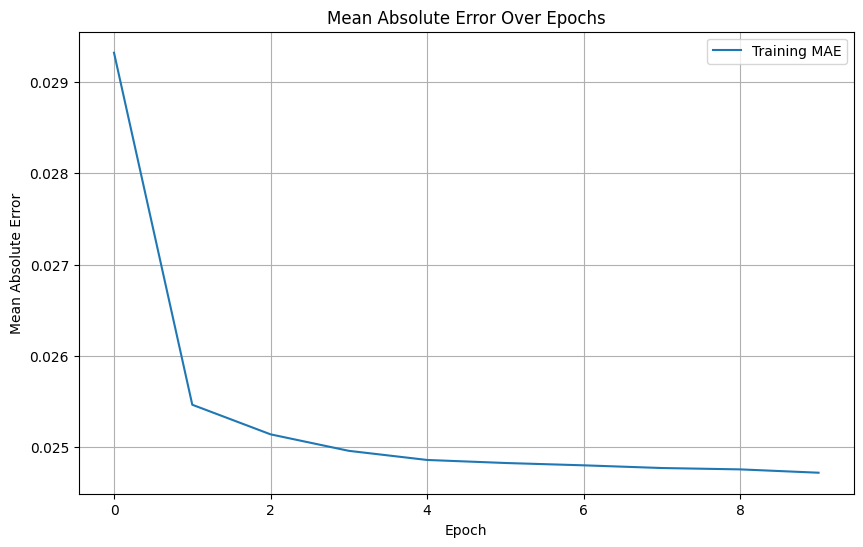

In [19]:
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(mae_history, label='Training MAE')
plt.title('Mean Absolute Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [21]:
mpe = sum(abs(y_pred.flatten() - y_test.to_numpy())/y_test.to_numpy())/len(y_test) * 100
print(mpe)

2.483950303521918
